In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sample1 = np.random.normal(loc=0, scale=1, size=100)
sample2 = np.random.normal(loc=0, scale=1, size=100)
sample3 = np.random.normal(loc=0, scale=1, size=100)
sample4 = np.random.normal(loc=0, scale=1, size=100)
sample5 = np.random.normal(loc=0, scale=1, size=100)

In [3]:
sample1

array([-0.2726864 ,  0.3153772 , -0.40499559,  0.09335514, -0.34389308,
       -0.47676265,  0.5089143 ,  0.45755347, -1.54327703,  1.49836153,
       -0.18639963,  2.18422193, -0.17179907, -0.17151564, -1.51000419,
       -1.43847664, -0.27534539,  0.25556205,  0.06701245, -0.5451253 ,
        0.90514431, -0.91328753, -1.02276156, -1.10860071,  2.33867292,
       -1.03634449,  2.21061887, -1.77576605,  0.35439242,  0.20941518,
        0.27161788, -1.10596126, -0.76038725, -0.22347742, -2.07409223,
        1.18360027, -0.01897861,  0.96174438,  0.39598025,  0.32889195,
        1.1468309 , -3.09580459,  0.85182301, -0.90244767,  0.12510486,
       -0.52959723, -0.78243211,  0.94678373, -0.66673922, -1.59314681,
        0.82192748, -0.0578555 ,  0.13596705,  1.78992571,  0.91884415,
       -0.47245734,  0.33340359, -0.82160301,  0.05496787,  1.05258212,
       -0.4817835 , -0.52399035, -1.52819034,  0.00471335, -0.6654635 ,
       -2.22973649, -0.23295798,  0.17966436, -0.56836292,  0.77

In [4]:
x = np.power(sample1, 2)
y = np.power(sample1, 2) + np.power(sample2, 2)
z = np.power(sample1, 2) + np.power(sample2, 2) + np.power(sample3, 2)
u = np.power(sample1, 2) + np.power(sample2, 2) + np.power(sample3, 2) + np.power(sample4, 2)
v = np.power(sample1, 2) + np.power(sample2, 2) + np.power(sample3, 2) + np.power(sample4, 2) + np.power(sample5, 2)

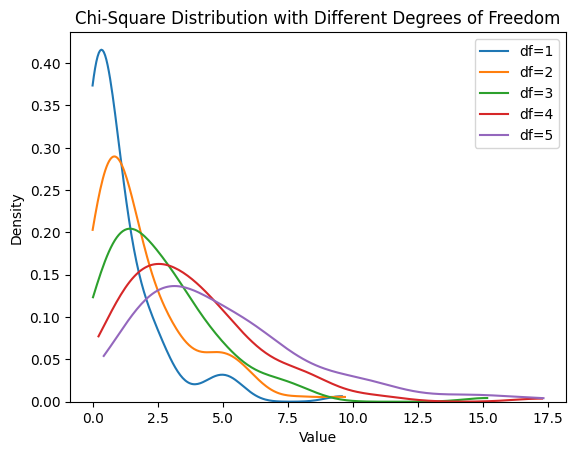

In [14]:
sns.kdeplot(x, clip=(x.min(), x.max()), label='df=1')
sns.kdeplot(y, clip=(y.min(), y.max()), label='df=2')
sns.kdeplot(z, clip=(z.min(), z.max()), label='df=3')
sns.kdeplot(u, clip=(u.min(), u.max()), label='df=4')
sns.kdeplot(v, clip=(v.min(), v.max()), label='df=5')
plt.legend()
plt.title('Chi-Square Distribution with Different Degrees of Freedom')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [17]:
import scipy.stats as stats

test_statistic = 9.95
degrees_of_freedom = 4

p_value = stats.chi2.sf(test_statistic, degrees_of_freedom)
print(f"Chi-Square Test Statistic: {p_value:.4f}")

Chi-Square Test Statistic: 0.0413


In [20]:
df = pd.read_csv('../../EDA/data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
class_counts = df['Pclass'].value_counts()


In [28]:
class_counts.sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [34]:
total_passengers = len(df)
expected_counts = total_passengers / 3
expected = [expected_counts] * 3
print(f"Expected Counts: {expected}")

Expected Counts: [297.0, 297.0, 297.0]


In [36]:
chi2, p_value = stats.chisquare(class_counts, expected)
print(f"Chi-Square Test Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-Square Test Statistic: 191.8047
P-value: 0.0000


In [37]:
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The distribution of passengers across classes is not uniform.")
else:
    print("Fail to reject the null hypothesis: The distribution of passengers across classes is uniform.")

Reject the null hypothesis: The distribution of passengers across classes is not uniform.


In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
contingency_table = pd.crosstab(df['Pclass'], df['Survived'])


In [40]:
contingency_table

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [44]:
chi2_statistic, p_value = stats.chisquare(contingency_table)

In [49]:
print("\nChi-Square Statistic: {:.2f}".format(chi2))
print("P-value: {:.4f}".format(p_value))


Chi-Square Statistic: 191.80


TypeError: unsupported format string passed to numpy.ndarray.__format__